In [1]:
import os
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.cm as cm


In [2]:
df_co2 = pd.read_csv(r'D:\Prog\ICRI\climate_change\paper_2\processed\emissions.csv').dropna(subset=['income_group'])
df_dash = pd.read_csv(r'D:\Prog\ICRI\climate_change\paper_2\processed\dash.csv').dropna(subset=['income_group'])
df_phdi = pd.read_csv(r'D:\Prog\ICRI\climate_change\paper_2\processed\phdi.csv').dropna(subset=['income_group'])
df_medit = pd.read_csv(r'D:\Prog\ICRI\climate_change\paper_2\processed\medit.csv').dropna(subset=['income_group'])

In [3]:


def _process_diet_data(df: pd.DataFrame, n_years: int = 7) -> pd.DataFrame:
    """
    Handles 'Wide' format data (Diet scores) where years are columns.
    Returns: DataFrame with [year, mean, ci_lo, ci_hi]
    """
    try:
        data_cols = df.columns[1:1 + n_years]
        cols_as_int = data_cols.astype(int)
    except Exception:
        data_cols = [c for c in df.columns if str(c).isdigit()][:n_years]
    
    if len(data_cols) == 0:
        return pd.DataFrame()

    mean = df[data_cols].mean(axis=0, numeric_only=True)
    std = df[data_cols].std(axis=0, ddof=1, numeric_only=True)
    n = df[data_cols].count(axis=0)
    
    se = std / np.sqrt(n.replace(0, np.nan))
    ci_lo = mean - 1.96 * se
    ci_hi = mean + 1.96 * se

    out_df = pd.DataFrame({
        "year": data_cols.astype(int),
        "mean": mean.values,
        "ci_lo": ci_lo.values,
        "ci_hi": ci_hi.values,
    })
    
    out_df["ci_lo"] = out_df["ci_lo"].fillna(out_df["mean"])
    out_df["ci_hi"] = out_df["ci_hi"].fillna(out_df["mean"])
    
    return out_df


def _process_co2_data(df: pd.DataFrame, n_rows: int = 7) -> pd.DataFrame:
    """
    Handles 'Long' format data (CO2).
    """
    if "year" not in df.columns or "emissions" not in df.columns:
        raise ValueError("CO2 DataFrame must contain 'year' and 'emissions' columns")

    grp = df.groupby("year")["emissions"]
    years = sorted(grp.groups.keys())
    
    rows = []
    target_years = years[:n_rows] if n_rows else years

    for y in target_years:
        s = grp.get_group(y).dropna()
        n = len(s)
        m = s.mean()
        
        if n > 1:
            sd = s.std(ddof=1)
            se = sd / np.sqrt(n)
            ci_half = 1.96 * se
        else:
            ci_half = 0

        rows.append({
            "year": int(y),
            "mean": m,
            "ci_lo": m - ci_half,
            "ci_hi": m + ci_half,
        })
    
    return pd.DataFrame(rows)


# -------------------------------------------------------------------------
# ANNOTATION HELPER
# -------------------------------------------------------------------------

def _annotate_grouped(
    ax: plt.Axes,
    entries: List[Dict],
    start_up: int = 10,
    start_down: int = -10
):
    groups: Dict[int, List[Dict]] = {}
    for e in entries:
        groups.setdefault(int(e["year"]), []).append(e)

    for year, items in groups.items():
        items_sorted = sorted(items, key=lambda x: x["value"], reverse=True)
        mid = (len(items_sorted) + 1) // 2
        above_items = items_sorted[:mid]
        below_items = items_sorted[mid:]

        for i, it in enumerate(above_items, start=1):
            ax.annotate(
                it["text"],
                (it["year"], it["value"]),
                textcoords="offset points",
                xytext=(0, start_up + (i * 2)),
                ha="center",
                fontsize=8,
                color=it["color"],
                weight="bold",
                bbox=dict(boxstyle="round,pad=0.1", edgecolor=it["color"], facecolor="white", alpha=0.8)
            )

        for i, it in enumerate(below_items, start=1):
            ax.annotate(
                it["text"],
                (it["year"], it["value"]),
                textcoords="offset points",
                xytext=(0, start_down - (i * 2)),
                ha="center",
                fontsize=8,
                color=it["color"],
                weight="bold",
                bbox=dict(boxstyle="round,pad=0.1", edgecolor=it["color"], facecolor="white", alpha=0.8)
            )

# -------------------------------------------------------------------------
# MAIN PLOTTING FUNCTION
# -------------------------------------------------------------------------

def plot_shaded_four_panel(
    df_co2: pd.DataFrame,
    df_phdi: pd.DataFrame,
    df_dash: pd.DataFrame,
    df_medit: pd.DataFrame,
    n_years: int = 7,
    figsize=(10, 14),
    dpi: int = 300,
    output_folder: str = "figures"
):
    """
    Plots 4 panels. CO2 legend top-right, others top-left. No bbox anchors.
    """

    # --- 1. Identify all unique income groups safely ---
    all_groups = set()
    for df in [df_co2, df_phdi, df_dash, df_medit]:
        if "income_group" in df.columns:
            uniques = df["income_group"].dropna().unique()
            all_groups.update(uniques)
    
    # Sort safely (strings)
    valid_groups = [g for g in all_groups if pd.notna(g)]
    sorted_groups = sorted(valid_groups, key=lambda x: str(x))
    
    # --- 2. Color Map Setup ---
    cmap = plt.get_cmap("tab10" if len(sorted_groups) <= 10 else "tab20")
    group_colors = {grp: cmap(i) for i, grp in enumerate(sorted_groups)}

    # --- 3. Setup Plot ---
    # sharex=False to show years on all plots
    fig, axes = plt.subplots(4, 1, figsize=figsize, dpi=dpi, sharex=False)
    ax_co2, ax_phdi, ax_dash, ax_medit = axes

    # Configuration: (Axis, DataFrame, Metric Name, Type, YLabel, Title, YLim)
    configs = [
        (ax_co2, df_co2, "co2", "long", "CO₂ Emissions (g)", "CO₂ Emissions", (1500,4500)),
        (ax_phdi, df_phdi, "phdi", "wide", "PHDI Score", "Planetary Health Diet Index", (60, 85)),
        (ax_dash, df_dash, "dash", "wide", "DASH Score", "DASH Diet Scores", (0, 3.5)),
        (ax_medit, df_medit, "medit", "wide", "Medit Score", "Mediterranean Diet Scores", (0, 7))
    ]

    # --- 4. Plotting Loop ---
    for ax, df, name, data_type, ylabel, title, ylim in configs:
        
        annotation_entries = []
        years_in_plot = set()
        group_counts = {}
        
        if "income_group" not in df.columns:
            print(f"Warning: 'income_group' column missing in {name}. Skipping.")
            continue

        for group_name, group_df in df.groupby("income_group"):
            
            if group_name not in group_colors:
                continue

            color = group_colors[group_name]
            
            # --- CALCULATE N FOR LEGEND ---
            if data_type == "long":
                n_years_data = group_df['year'].nunique()
                n_count = int(len(group_df) / n_years_data) if n_years_data > 0 else 0
            else:
                n_count = len(group_df)
            
            group_counts[group_name] = n_count

            # Process Data
            if data_type == "long":
                stats = _process_co2_data(group_df, n_rows=n_years)
                val_fmt = lambda x: f"{int(x)}"
                marker = "o"
            else:
                stats = _process_diet_data(group_df, n_years=n_years)
                val_fmt = lambda x: f"{x:.1f}"
                marker = "s" if name in ["dash", "phdi"] else "v"

            if stats.empty:
                continue

            years_in_plot.update(stats["year"].tolist())

            # Plot Line & Markers
            ax.plot(stats["year"], stats["mean"], marker=marker, color=color, label=str(group_name))
            
            # Collect points for annotation
            for _, r in stats.iterrows():
                annotation_entries.append({
                    "year": r["year"],
                    "value": r["mean"],
                    "text": val_fmt(r["mean"]),
                    "color": color
                })

        # Apply Axis Settings
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(alpha=0.3)
        if ylim:
            ax.set_ylim(ylim)
        
        # Set X Ticks
        if years_in_plot:
            sorted_years = sorted(list(years_in_plot))
            ax.set_xticks(sorted_years)
            ax.set_xticklabels([int(y) for y in sorted_years])
        
        if name == "co2":
            ax.axvline(x=2018, color="lightgray", linestyle="--", linewidth=0.7)

        # Annotate
        _annotate_grouped(ax, annotation_entries)
        
        # --- BUILD LEGEND WITH COUNTS ---
        handles = []
        for grp in sorted_groups:
            if grp in group_counts:
                c = group_colors[grp]
                count = group_counts[grp]
                label_text = f"{grp} (n={count})"
                h = Line2D([0], [0], color=c, marker='o', label=label_text)
                handles.append(h)
        
        if handles:
            # Determine location based on plot name
            if name == "co2":
                legend_loc = "upper right"
            else:
                legend_loc = "upper left"

            # Added conditional location, removed bbox_to_anchor
            ax.legend(
                handles=handles, 
                title='Income Group', 
                loc=legend_loc, 
                fontsize=9, 
                framealpha=0.9
            )

    plt.tight_layout()
    
    os.makedirs(output_folder, exist_ok=True)
    out_path = os.path.join(output_folder, "income_group_comparison.png")
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    print(f"Plot saved to {out_path}")
    plt.show()

# plot_shaded_four_panel(df_co2, df_phdi, df_dash, df_medit, n_years=7)

Plot saved to figures\income_group_comparison.png


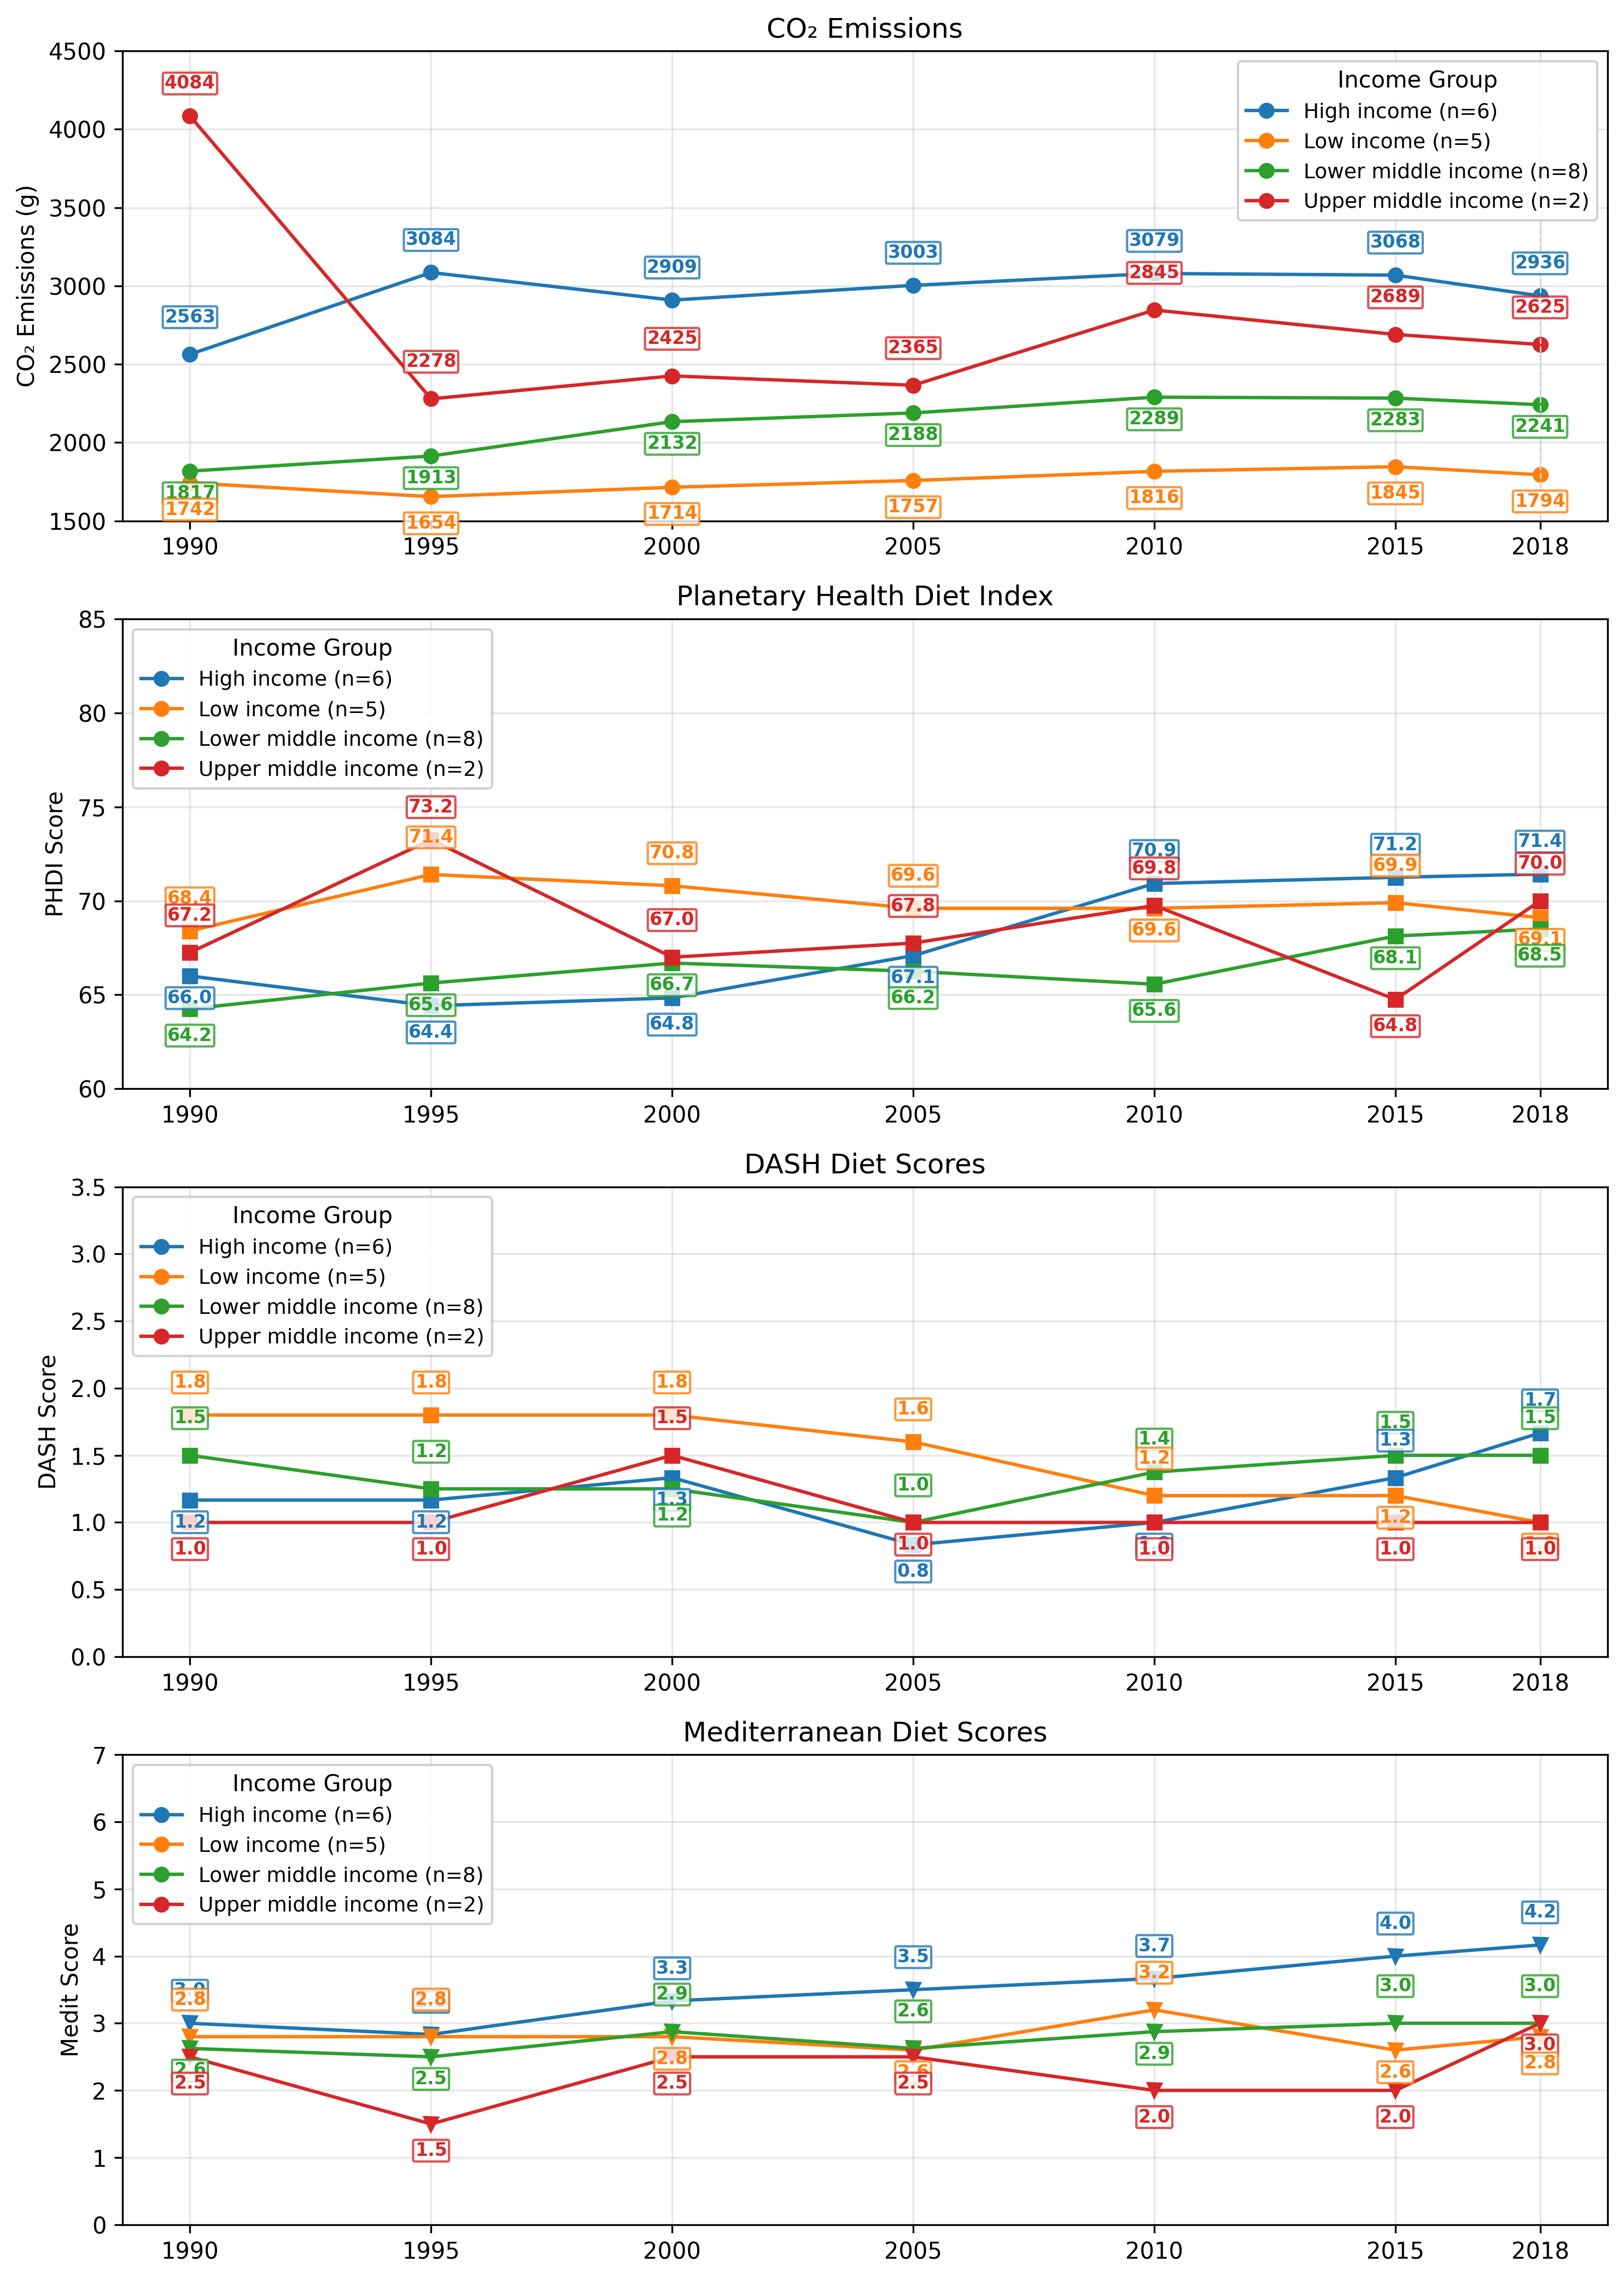

In [4]:
plot_shaded_four_panel(
    df_co2=df_co2,   # Must have: income_group, year, emissions
    df_phdi=df_phdi, # Must have: income_group, 2010, 2015...
    df_dash=df_dash, # Must have: income_group, 2010, 2015...
    df_medit=df_medit, # Must have: income_group, 2010, 2015...
    n_years=7
)